# <font color='Blue'>Projeto Ponta a Ponta - Construindo um Modelo com TensorFlow (Fashion MNIST) </font>

**Pipeline de um Projeto de IA:**
1. Definição do problema
2. Coleta dos dados
3. Pré-processamento
4. Construção do modelo
5. Treinamento
6. Avaliação
7. Deploy / inferência

**Objetivos do Projeto:**
* Construir um modelo de **Deep Learning com TensorFlow/Keras** usando o dataset **Fashion MNIST**.

**Dataset utilizado:** Fashion MNIST  
**Referência**: https://keras.io/api/datasets/fashion_mnist/


In [ ]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.12.13


In [ ]:
# TensorFlow normalmente já vem instalado no Google Colab.
# !pip install -q tensorflow

import tensorflow as tf
print('Versão do TensorFlow:', tf.__version__)

Versão do TensorFlow: 2.19.0


In [ ]:
# Silencia mensagens menos importantes do TensorFlow
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [ ]:
# Imports
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

## Carregando os Dados - Matéria-Prima

O **Fashion MNIST** contém imagens em **tons de cinza** de peças de roupa, com tamanho **28 x 28 pixels**.

Cada imagem pertence a uma das 10 classes:
- **T-shirt/top** — Camiseta/Top
- **Trouser** — Calça
- **Pullover** — Pulôver
- **Dress** — Vestido
- **Coat** — Casaco
- **Sandal** — Sandália
- **Shirt** — Camisa
- **Sneaker** — Tênis
- **Bag** — Bolsa
- **Ankle boot** — Bota


In [ ]:
# Carrega o dataset Fashion MNIST - já está disponível no Keras
(imagens_treino, labels_treino), (imagens_teste, labels_teste) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Classes das imagens
nomes_classes = [
    'Camiseta/Top', 'Calça', 'Pulôver', 'Vestido', 'Casaco',
    'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota'
]

In [ ]:
# Formato dos dados
print('Formato das imagens de treino:', imagens_treino.shape)
print('Formato das labels de treino:', labels_treino.shape)
print('Formato das imagens de teste:', imagens_teste.shape)
print('Formato das labels de teste:', labels_teste.shape)

Formato das imagens de treino: (60000, 28, 28)
Formato das labels de treino: (60000,)
Formato das imagens de teste: (10000, 28, 28)
Formato das labels de teste: (10000,)


## Pré-processamento e visualização das imagens

In [ ]:
# Normaliza os valores dos pixels para a faixa [0, 1]
imagens_treino = imagens_treino.astype('float32') / 255.0
imagens_teste = imagens_teste.astype('float32') / 255.0

# Adiciona o canal das imagens para usar CNN com Conv2D
# Antes: (amostras, 28, 28)
# Depois: (amostras, 28, 28, 1)
imagens_treino = np.expand_dims(imagens_treino, axis=-1)
imagens_teste = np.expand_dims(imagens_teste, axis=-1)

print('Novo formato das imagens de treino:', imagens_treino.shape)
print('Novo formato das imagens de teste:', imagens_teste.shape)

Novo formato das imagens de treino: (60000, 28, 28, 1)
Novo formato das imagens de teste: (10000, 28, 28, 1)


In [ ]:
# Função para exibir as imagens
def visualiza_imagens(images, labels, class_names, n_linhas=3, n_colunas=5):
    plt.figure(figsize=(10, 7))
    total = n_linhas * n_colunas

    for i in range(total):
        plt.subplot(n_linhas, n_colunas, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.xlabel(class_names[int(labels[i])])

    plt.tight_layout()
    plt.show()

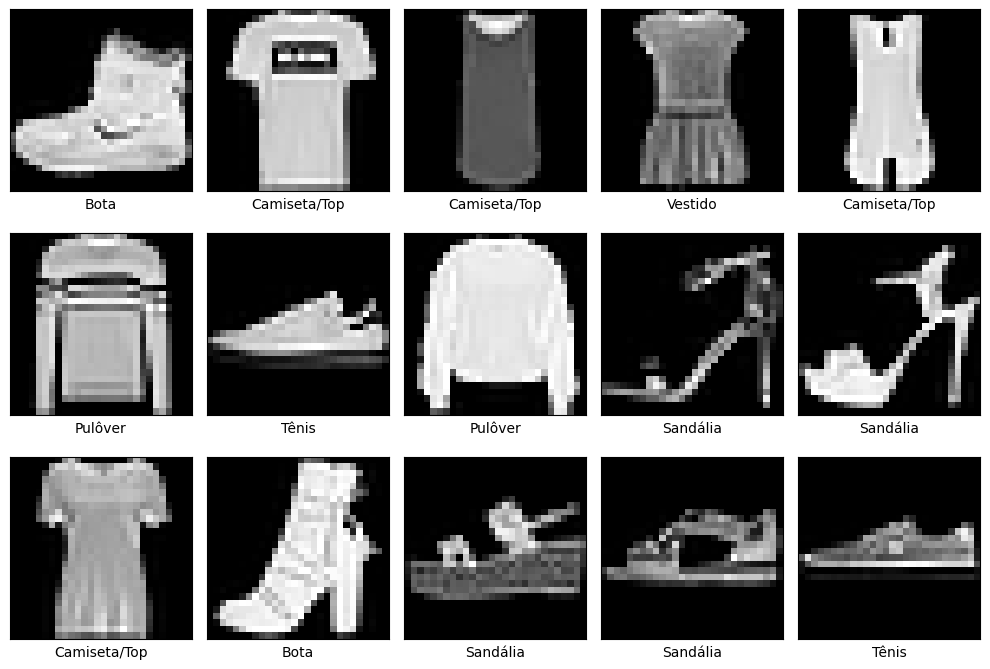

In [ ]:
# Executa a função
visualiza_imagens(imagens_treino, labels_treino, nomes_classes)

## Construção do modelo

In [ ]:
# Arquitetura do modelo -> Feature Learning + Classificação
modelo_lia = models.Sequential()

modelo_lia.add(layers.Input(shape=(28, 28, 1)))
modelo_lia.add(layers.Conv2D(32, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

modelo_lia.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

modelo_lia.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Camadas de classificação
modelo_lia.add(layers.Flatten())
modelo_lia.add(layers.Dense(64, activation='relu'))
modelo_lia.add(layers.Dropout(0.3))
modelo_lia.add(layers.Dense(10, activation='softmax'))

In [ ]:
# Sumário do modelo
modelo_lia.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilação do modelo
modelo_lia.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
%%time
# Treinamento do modelo
# Aqui é utilizado validation_split para separar uma parte do conjunto de treino
# e preservar o conjunto de teste apenas para a avaliação final.
history = modelo_lia.fit(
    imagens_treino,
    labels_treino,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7596 - loss: 0.6646 - val_accuracy: 0.8522 - val_loss: 0.4106
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.8518 - loss: 0.4146 - val_accuracy: 0.8698 - val_loss: 0.3572
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.8751 - loss: 0.3518 - val_accuracy: 0.8832 - val_loss: 0.3188
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.8864 - loss: 0.3173 - val_accuracy: 0.8913 - val_loss: 0.2979
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.8945 - loss: 0.2919 - val_accuracy: 0.8961 - val_loss: 0.2792
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9018 - loss: 0.2714 - val_accuracy: 0.8963 - val_loss: 0.2790
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9085 - loss: 0.2539 - val_accuracy: 0.8932 - val_loss: 0.2934
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9129 - loss: 0.2399 - 

## Curvas de treinamento

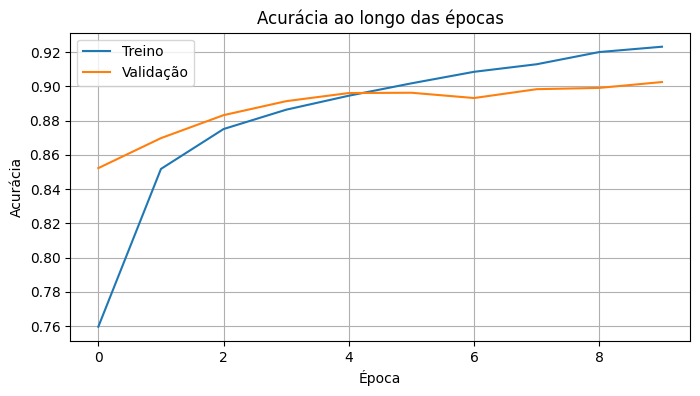

In [ ]:
# Histórico de accuracy e loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia ao longo das épocas')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

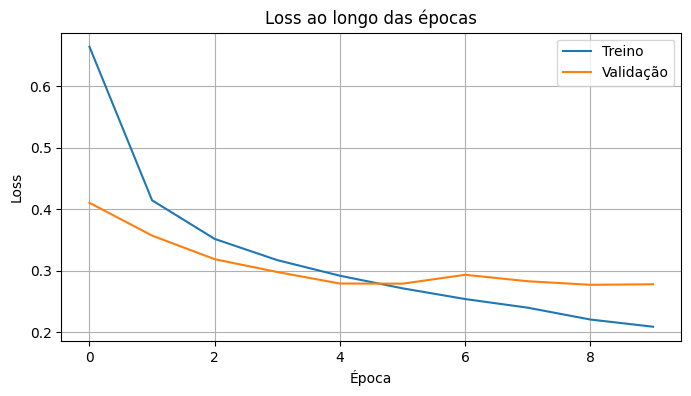

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss ao longo das épocas')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Avaliação do modelo

In [ ]:
# Avalia o modelo com o conjunto de teste
erro_teste, acc_teste = modelo_lia.evaluate(imagens_teste, labels_teste, verbose=2)

313/313 - 2s - 6ms/step - accuracy: 0.9008 - loss: 0.2909


In [ ]:
print('\nLoss com dados de teste:', erro_teste)
print('Acurácia com dados de teste:', acc_teste)


Loss com dados de teste: 0.29091331362724304
Acurácia com dados de teste: 0.9007999897003174


In [ ]:
# Previsões do modelo no conjunto de teste
y_pred = modelo_lia.predict(imagens_teste)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = labels_teste

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


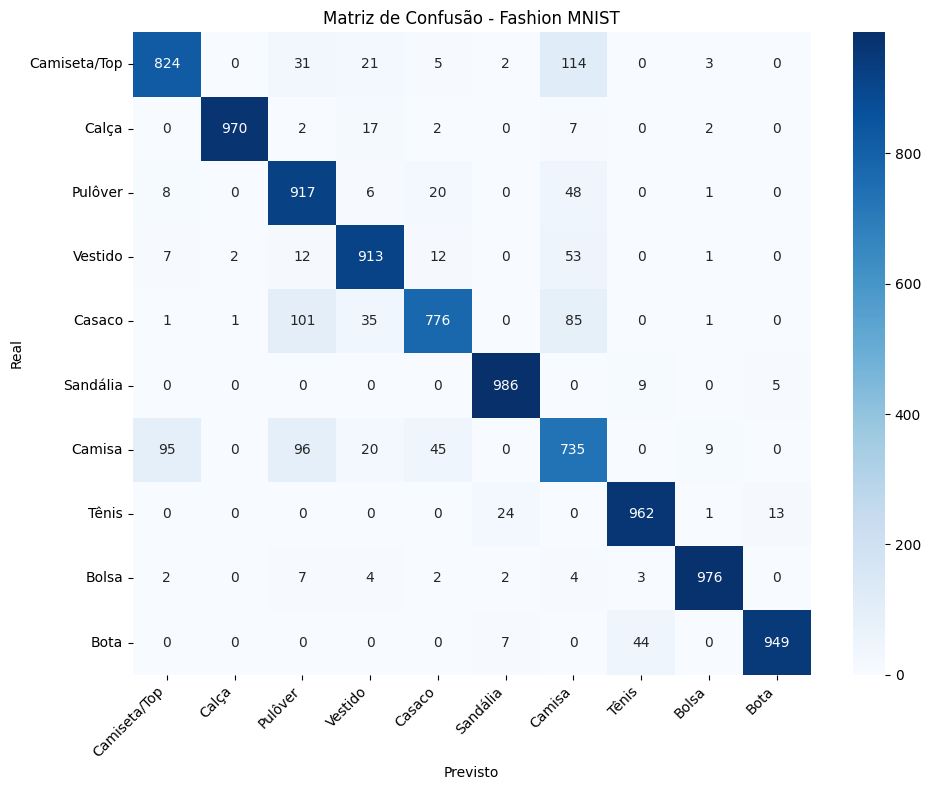

In [ ]:
# Matriz de confusão
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Fashion MNIST')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Relatório de classificação
print(classification_report(y_true, y_pred_classes, target_names=nomes_classes))

              precision    recall  f1-score   support

Camiseta/Top       0.88      0.82      0.85      1000
       Calça       1.00      0.97      0.98      1000
     Pulôver       0.79      0.92      0.85      1000
     Vestido       0.90      0.91      0.91      1000
      Casaco       0.90      0.78      0.83      1000
    Sandália       0.97      0.99      0.98      1000
      Camisa       0.70      0.73      0.72      1000
       Tênis       0.94      0.96      0.95      1000
       Bolsa       0.98      0.98      0.98      1000
        Bota       0.98      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## Visualizando previsões do modelo

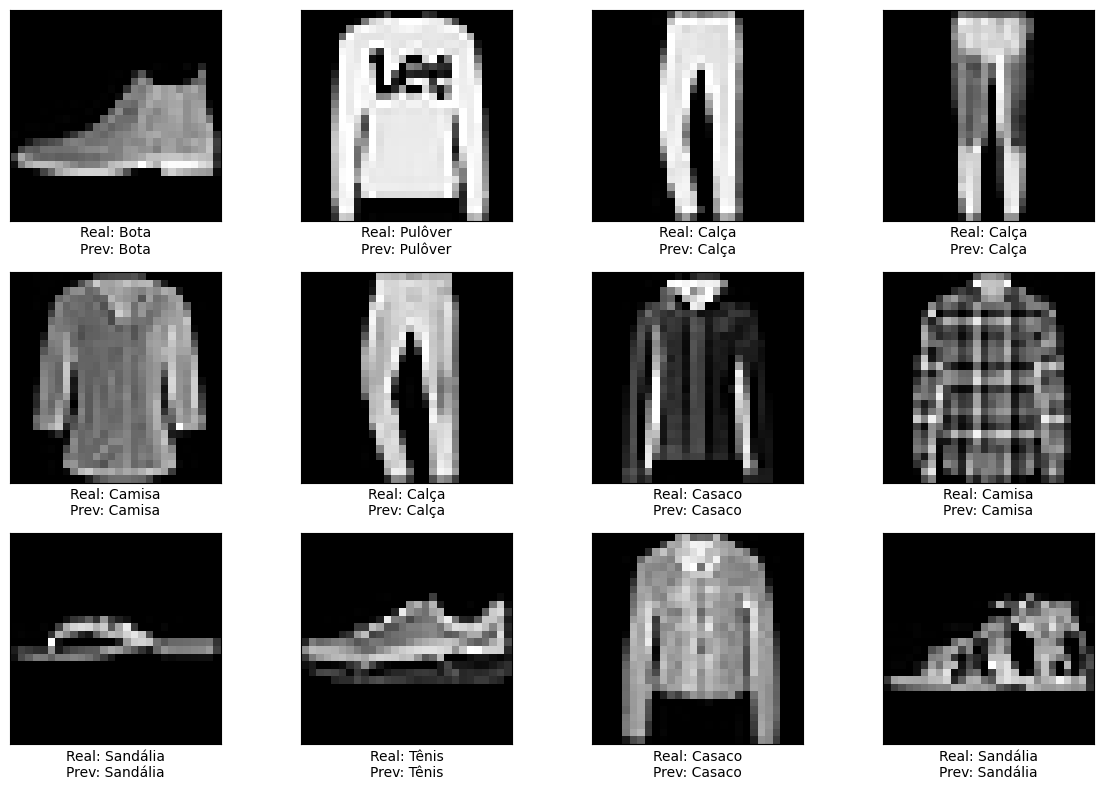

In [ ]:
# Exibe algumas previsões do modelo
def mostra_previsoes(images, y_real, y_prev, nomes_classes, quantidade=12):
    plt.figure(figsize=(12, 8))
    for i in range(quantidade):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        classe_real = nomes_classes[int(y_real[i])]
        classe_prev = nomes_classes[int(y_prev[i])]

        plt.xlabel(f'Real: {classe_real}\nPrev: {classe_prev}')

    plt.tight_layout()
    plt.show()

mostra_previsoes(imagens_teste, y_true, y_pred_classes, nomes_classes)

## Deploy do modelo / inferência

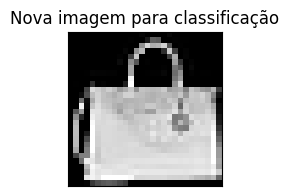

Classe real: Bolsa


In [ ]:
# Seleciona uma imagem do conjunto de teste como se fosse uma nova imagem
indice = 30

nova_imagem = imagens_teste[indice]
label_real = labels_teste[indice]

plt.figure(figsize=(2, 2))
plt.imshow(nova_imagem.squeeze(), cmap='gray')
plt.xticks([])
plt.yticks([])
plt.title('Nova imagem para classificação')
plt.show()

print('Classe real:', nomes_classes[int(label_real)])

In [ ]:
# Expande a dimensão para o formato (1, 28, 28, 1)
nova_imagem_array = np.expand_dims(nova_imagem, axis=0)
print('Formato da nova imagem:', nova_imagem_array.shape)

Formato da nova imagem: (1, 28, 28, 1)


In [ ]:
# Previsão da nova imagem
previsoes = modelo_lia.predict(nova_imagem_array)
print('Probabilidades previstas:')
print(previsoes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Probabilidades previstas:
[[1.0313333e-13 4.4071055e-17 2.2777601e-15 2.8012733e-17 2.3093466e-13
  8.3224445e-18 1.2333616e-15 5.7560514e-15 1.0000000e+00 1.8799820e-18]]


In [ ]:
# Obtém a classe com maior probabilidade
classe_prevista = np.argmax(previsoes, axis=1)[0]
nome_classe_prevista = nomes_classes[int(classe_prevista)]

print('A nova imagem foi classificada como:', nome_classe_prevista)

A nova imagem foi classificada como: Bolsa


## Teste com imagem local externa

Nesta seção, você pode carregar uma imagem do seu computador (por exemplo, uma roupa baixada da internet) e verificar como o modelo a classifica.

**Observações importantes:**
- O modelo espera imagens em **tons de cinza**;
- A imagem será convertida para **28 x 28 pixels**;
- Em muitas imagens da internet, o item aparece **escuro em fundo claro**; nesse caso, pode ser necessário **inverter os pixels** para se aproximar do padrão visual do Fashion MNIST.


In [ ]:
# Imports para teste com imagem local
from PIL import Image

try:
    from google.colab import files
    ambiente_colab = True
except ImportError:
    ambiente_colab = False

print('Executando no Google Colab?' , ambiente_colab)


Executando no Google Colab? True


In [ ]:
# Upload da imagem no Google Colab
# Se estiver no Colab, execute esta célula e escolha uma imagem do seu computador.
# Se não estiver no Colab, informe manualmente o caminho do arquivo na célula seguinte.

if ambiente_colab:
    uploaded = files.upload()
    caminho_imagem = list(uploaded.keys())[0]
    print('Arquivo enviado:', caminho_imagem)
else:
    print('Se você não estiver no Colab, pule esta célula e use a próxima para informar o caminho da imagem.')


Saving images1.jpg to images1.jpg
Arquivo enviado: images1.jpg


In [ ]:
# Caminho manual da imagem
# Use esta célula se a imagem já estiver salva no ambiente do notebook.
# Exemplo: caminho_imagem = '/content/minha_roupa.jpg'

# caminho_imagem = '/content/minha_roupa.jpg'
print('Defina a variável caminho_imagem caso não tenha feito upload na célula anterior.')


Defina a variável caminho_imagem caso não tenha feito upload na célula anterior.


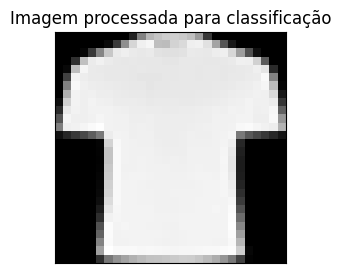

In [ ]:
# Pré-processamento da imagem local
# Ordem adotada: abrir -> converter para cinza -> redimensionar -> normalizar -> inverter (opcional)

inverter_pixels = True  # Troque para False se a imagem já estiver clara em fundo escuro

img = Image.open(caminho_imagem)
img = img.convert('L')
img = img.resize((28, 28))

img_array = np.array(img).astype('float32') / 255.0

if inverter_pixels:
    img_array = 1.0 - img_array

plt.figure(figsize=(3, 3))
plt.imshow(img_array, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.title('Imagem processada para classificação')
plt.show()


In [ ]:
# Ajusta o formato da imagem para o padrão esperado pela CNN: (1, 28, 28, 1)
img_array = np.expand_dims(img_array, axis=-1)
img_array = np.expand_dims(img_array, axis=0)

print('Formato final da imagem:', img_array.shape)


Formato final da imagem: (1, 28, 28, 1)


In [ ]:
# Classificação da imagem local
pred_local = modelo_lia.predict(img_array)
classe_prevista_local = np.argmax(pred_local, axis=1)[0]

print('Probabilidades previstas:')
print(pred_local)
print('Classe prevista para a imagem local:', nomes_classes[int(classe_prevista_local)])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Probabilidades previstas:
[[9.9658233e-01 2.8581213e-09 1.1301871e-04 7.0113299e-07 2.8458226e-07
  1.8364254e-07 3.2978673e-03 6.1123689e-11 5.7374891e-06 6.9931416e-10]]
Classe prevista para a imagem local: Camiseta/Top


## Observação importante

Como o **Fashion MNIST** possui imagens em **tons de cinza** e com dimensão **28 x 28**, foi necessário:

- trocar o carregamento do dataset de `cifar10` para `fashion_mnist`
- adaptar o formato de entrada da rede para `(28, 28, 1)`
- usar visualização com `cmap='gray'`
- expandir a dimensão do canal das imagens
- ajustar a lista de classes para as roupas e acessórios do dataset

Se você chegou até aqui, parabéns! 🎆 🔥

Você adaptou um projeto de classificação de imagens com TensorFlow para o dataset **Fashion MNIST**.